## Module 4: 

## Team Members:
Isabella Imburgia and Zain Abed

## Project Title:
Resisting Apoptosis and Uterine Cancer 



## Project Goal:
This project seeks to examine the effects of resisting apoptosis on uterine corpus endometrial carcinoma. There are numerous questions that can be asked relating to this such as:
1. Do more aggressive UCEC histologic subtypes, which may reflect greater resistance to apoptosis, show worse survival outcomes?
2. Is tumor status associated with prognosis in UCEC?
3. Are demographic features linked to outcome difference in UCEC?

When creating the main learning model, the focused question will be: Can expression patterns of apoptosis-related genes in UCEC be used to accurately classify histologic subtypes, and is tumor status associated with prognosis as measured by a survival outcome?

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus: resisting apoptosis
* Overview of hallmark: In healthy tissue, apoptosis is controlled form of programmed cell death. It protects the body by eliminating cells with severe DNA damage, dangerous mutations, or abnormal growth signals. When this works, potentially cancerous cells are often destroyed before they can expand. Cancer cells become dangerous because they can learn to block or bypass apoptosis. That lets them survive when they should die. As a result, cells with harmful mutations can keep dividing, accumulate more changes, and form tumors.
* ****Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest) p53 and PI3k/AKT

### Uterine Corpus Endometrial Carcinoma 

* Prevalence & incidence 

Uterine cancer is the most common form of gynecologic cancer in the United States. There have been 69,120 new cases reported in the US in 2025 with an incidence of approximately 28.3 per 100,000 women. There were 13,860 deaths from this form of cancer in 2025. 
* Risk factors (genetic, lifestyle) & Societal determinants

Uterine cancer is most commonly caused by a hormone imbalance, specifically in this case prolonged estrogen exposure. Risk factors include obesity, type 2 diabetes, irregular onset of menopause, polycystic ovary syndrome (PCOS), and other metabolic conditions. The American Cancer Society reports that there are societal factors with Black women dying of endometrial cancer at nearly twice the rate of white women. There is also a higher mortality rate in non-Hispanic Black women and this disparity is thought to be caused by a lack of accessible healthcare in rural or low-income areas. 

* Standard of care treatments (& reimbursement) 

For early stage uterine or endometrial cancer, the treatment is normally a full hysterectomy to completely remove the uterus and the cancer. If the cancer has progressed, then chemotherapy or radiation may be necessary. There are a limited number of FDA approved drugs to treat advanced or recurring endometrial carcinoma and reibursement for these treatments depends on the type of drug and the stage of cancer, it is not a national standard covered by Medicare. 


* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

Biologically, uterine corpus endometrial carcinoma (UCEC) develops from the endometrium, the hormonally responsive inner lining of the uterus, where normal cell growth and shedding are regulated by estrogen and progesterone. When the endometrium is exposed to prolonged unopposed estrogen, it can become hyperplastic and, over time, progress to malignancy, especially in endometrioid tumors, which are often considered Type 1 and are more hormone-related. In contrast, Type 2 tumors, such as serous endometrial adenocarcinoma, are typically less hormone-driven and more aggressive. At the cellular and molecular level, UCEC develops when normal controls over proliferation, DNA damage response, and cell death break down. One important cancer hallmark in this disease is resisting apoptosis, meaning tumor cells avoid the programmed cell death that would normally eliminate abnormal or damaged cells. This can happen through disruption of pathways involving p53, PI3K/AKT, and other regulators of survival signaling, allowing malignant cells to persist, accumulate further changes, and become more resistant to treatment.
https://www.cancer.gov/types/uterine/hp/endometrial-treatment-pdq
https://www.cancer.org/cancer/types/endometrial-cancer/about/key-statistics.html 

## Data-Set: 

*ChatGPT was used to help improve clarity and check for errors in writing and spelling.*
*OpenAI. (2026). ChatGPT (GPT-5 mini) [Large language model]. [https://openai.com/chatgpt](https://openai.com/chatgpt)*

The dataset comes from The Cancer Genome Atlas RNA-seq dataset, which was reprocessed by Rahman et al., who used DNA and RNA sequencing to obtain molecular data on the 11,000 tumor samples collected. The tumor samples were then subsetted by Professor Groves to include 50–100 tumor samples for each respective cancer type. The metadata regarding patients was also reduced to roughly 20 columns out of the original 526 to focus on the categories best suited for this project.

As stated earlier, the goal of the project is to examine the effects of resisting apoptosis on UCEC. To do this, we will examine the molecular data of tumors from UCEC patients, specifically looking at the levels of tumor suppressors such as p53 and PI3K/AKT, which in this dataset are measured using log-transformed TPM values. Additionally, in order to answer our follow-up questions, the metadata needs to be analyzed. For the first two, we need to examine the histological diagnosis of the tumors along with the disease-free interval (DFI), the progression-free interval (PFI), and overall survival (OS), all of which are measured in months. For the third question, along with OS, PFI, and DFI, we would like to examine race to determine if there is variability in outcomes between demographics.



## Data Analysis

In [2]:
#Claude was used to assist with code debugging and error diagnosis. Anthropic. (2026). Claude (Claude Sonnet 4.6) [Large language model]. https://claude.ai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
# ── Load the data ──────────────────────────────────────────────────────────────
data = pd.read_csv(
    #'/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    '/Users/ajq2af/OneDrive - University of Virginia\Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0, header=0
)
metadata_df = pd.read_csv(
    #'/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_metadata.csv',
    '/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0, header=0
)
 
# ── Explore the data ───────────────────────────────────────────────────────────
print(data.shape)
print(data.info())
print(data.describe())
 
# ── Explore the metadata ───────────────────────────────────────────────────────
print(metadata_df.info())
print(metadata_df.describe())
 
# ── Subset data for a specific cancer type ─────────────────────────────────────
cancer_type = 'UCEC'
 
# Strip whitespace to avoid silent mismatches
data.columns = data.columns.str.strip()
metadata_df.index = metadata_df.index.str.strip()
 
# Get sample IDs for the target cancer type
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)
print(cancer_samples)
 
# Subset the main data to include only UCEC samples
UCEC_data = data[common_samples]

(15716, 1802)
<class 'pandas.core.frame.DataFrame'>
Index: 15716 entries, A1BG to ZZZ3
Columns: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
dtypes: float64(1802)
memory usage: 216.2+ MB
None
       TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
count                  15716.000000                  15716.000000   
mean                       3.819608                      3.695116   
std                        2.367493                      2.448152   
min                        0.000000                      0.000000   
25%                        1.936472                      1.630385   
50%                        3.906571                      3.775523   
75%                        5.435952                      5.426145   
max                       12.964224                     14.202553   

       TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
count                  15716.000000                  15716.000000   
mean              

First, the expression matrix and accompanying patient metadata are read and then  their dimensions and basic statistics are explored to confirm successful loading. To focus the analysis on uterine corpus endometrial carcinoma (UCEC), the dataset is filtered to only include samples labeled as UCEC in the metadata. This reduces the dataset from the full multi-cancer cohort to only the relevant tumor samples, allowing for the examination of apoptosis-related gene expression specifically within this cancer type.

In [3]:
# ── Gene subsetting ────────────────────────────────────────────────────────────
desired_gene_list = ['TP53', 'AKT1']
gene_list = [g for g in desired_gene_list if g in UCEC_data.index]
 
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")
 
# .loc[] subsets by index label; .iloc[] subsets by integer position
UCEC_gene_data = UCEC_data.loc[gene_list]  # uses validated gene_list (safe)
print(UCEC_gene_data.head())
 
# ── Basic statistics on subsetted gene data ────────────────────────────────────
print(UCEC_gene_data.describe())
print(UCEC_gene_data.var(axis=1))     # Variance of each gene across samples
print(UCEC_gene_data.mean(axis=1))    # Mean expression per gene
print(UCEC_gene_data.median(axis=1))  # Median expression per gene

      TCGA-SL-A6J9-01A-11R-A31O-07  TCGA-AX-A3G9-01A-11R-A22K-07  \
TP53                      3.129795                      6.535524   
AKT1                      7.361699                      7.110363   

      TCGA-AJ-A3BH-01A-11R-A19W-07  TCGA-EY-A212-01A-11R-A14M-07  \
TP53                      6.676882                      7.521993   
AKT1                      7.628104                      7.923680   

      TCGA-AJ-A8CV-01A-11R-A37O-07  TCGA-BG-A0LW-01A-11R-A16W-07  \
TP53                      6.612640                      6.677274   
AKT1                      7.158538                      7.294814   

      TCGA-AX-A1C4-01A-11R-A137-07  TCGA-AX-A3FV-01A-11R-A22K-07  \
TP53                      8.366161                      6.188199   
AKT1                      7.506902                      7.587461   

      TCGA-B5-A1MZ-01A-11R-A144-07  TCGA-A5-A3LO-01A-11R-A22K-07  ...  \
TP53                      7.445360                      6.639341  ...   
AKT1                      7.111554

Rather than analyzing all genes in the dataset, it is narrowed to focus on a curated list of approximately 100 genes known to be involved in apoptosis regulation, survival signaling, and DNA damage response. This gene selection is directly related to the hallmark of interest, resisting apoptosis, and is relevant to the molecular methods of UCEC and each subtype.

Average OS time for UCEC: 1091.66
                                  TP53      AKT1 cancer_type  \
TCGA-SL-A6J9-01A-11R-A31O-07  3.129795  7.361699        UCEC   
TCGA-AX-A3G9-01A-11R-A22K-07  6.535524  7.110363        UCEC   
TCGA-AJ-A3BH-01A-11R-A19W-07  6.676882  7.628104        UCEC   
TCGA-EY-A212-01A-11R-A14M-07  7.521993  7.923680        UCEC   
TCGA-AJ-A8CV-01A-11R-A37O-07  6.612640  7.158538        UCEC   

                             bcr_patient_barcode  gender  \
TCGA-SL-A6J9-01A-11R-A31O-07        TCGA-SL-A6J9  FEMALE   
TCGA-AX-A3G9-01A-11R-A22K-07        TCGA-AX-A3G9  FEMALE   
TCGA-AJ-A3BH-01A-11R-A19W-07        TCGA-AJ-A3BH  FEMALE   
TCGA-EY-A212-01A-11R-A14M-07        TCGA-EY-A212  FEMALE   
TCGA-AJ-A8CV-01A-11R-A37O-07        TCGA-AJ-A8CV  FEMALE   

                                                   race  \
TCGA-SL-A6J9-01A-11R-A31O-07  BLACK OR AFRICAN AMERICAN   
TCGA-AX-A3G9-01A-11R-A22K-07                      WHITE   
TCGA-AJ-A3BH-01A-11R-A19W-07               

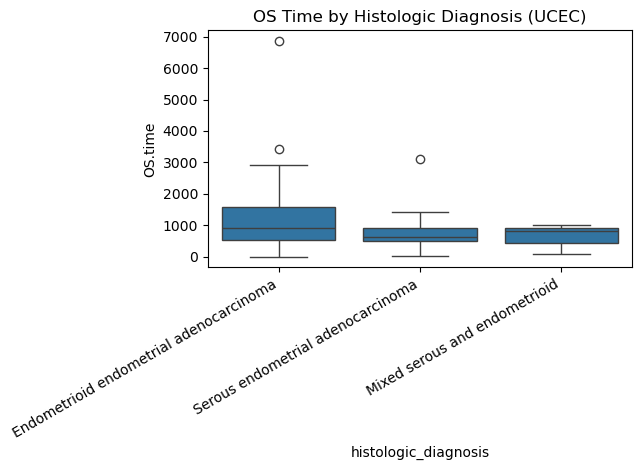

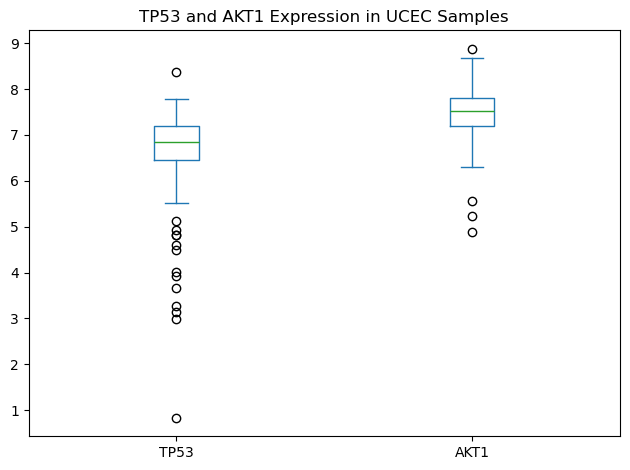

In [4]:
# ── Survival time summary for UCEC ────────────────────────────────────────────
metadata_df['OS.time'] = pd.to_numeric(metadata_df['OS.time'], errors='coerce')
filtered_df = metadata_df[metadata_df['cancer_type'] == cancer_type]
avg_OStime = filtered_df['OS.time'].mean()
print(f"Average OS time for {cancer_type}: {avg_OStime:.2f}")
 
# ── Merge expression data with metadata ───────────────────────────────────────
# Transpose so rows = samples, columns = genes
gene_df = UCEC_gene_data.T
UCEC_metadata = metadata_df.loc[common_samples]  # align to common_samples
UCEC_merged = gene_df.merge(UCEC_metadata, left_index=True, right_index=True)
print(UCEC_merged.head())
 
# ── Plotting ───────────────────────────────────────────────────────────────────
# Boxplot: histological diagnosis vs. OS time (Seaborn)
plt.figure()
sns.boxplot(
    data=UCEC_merged,
    x='histologic_diagnosis',
    y='OS.time'
)
plt.title(f"OS Time by Histologic Diagnosis ({cancer_type})")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
 
# Boxplot: TP53 and AKT1 expression in UCEC samples (Pandas)
available_genes = [g for g in ['TP53', 'AKT1'] if g in UCEC_merged.columns]
UCEC_merged[available_genes].plot.box()
plt.title(f"TP53 and AKT1 Expression in {cancer_type} Samples")
plt.tight_layout()
plt.show()

The basic descriptive statistics are computed for each gene across all UCEC samples, including variance, mean, and median expression levels. High variance genes indicate genes whose expression differs meaningfully across patients and may be relevant to distinguishing subtypes. The average overall survival (OS) time for UCEC patients in this dataset was calculated as an initial look at prognosis. OS time is measured in days and represents one of the primary outcome variables for evaluating whether molecular subtypes are associated with survival differences. To enable combined analysis of gene expression and clinical outcomes, the expression data with patient metadata on sample ID is merged. The resulting dataframe contains both gene expression values and clinical variables such as histologic diagnosis, OS time, and demographic information for each patient. This boxplot compares overall survival time across the three histologic subtypes present in our UCEC cohort: endometrioid endometrial adenocarcinoma, serous endometrial adenocarcinoma, and mixed serous and endometrioid. If more aggressive subtypes, such as serous, show shorter OS times, this would support the hypothesis that greater resistance to apoptosis is associated with worse survival outcomes. The second box plot visualizes the expression distributions of TP53 and AKT1, two central regulators of apoptosis resistance in UCEC. TP53 encodes the p53 tumor suppressor, which normally triggers apoptosis in response to DNA damage. AKT1 is a key component of the PI3K/AKT survival signaling pathway, which promotes cell survival and inhibits apoptosis. Differences in their expression levels across samples reflect the variability in apoptotic signaling within the cohort.

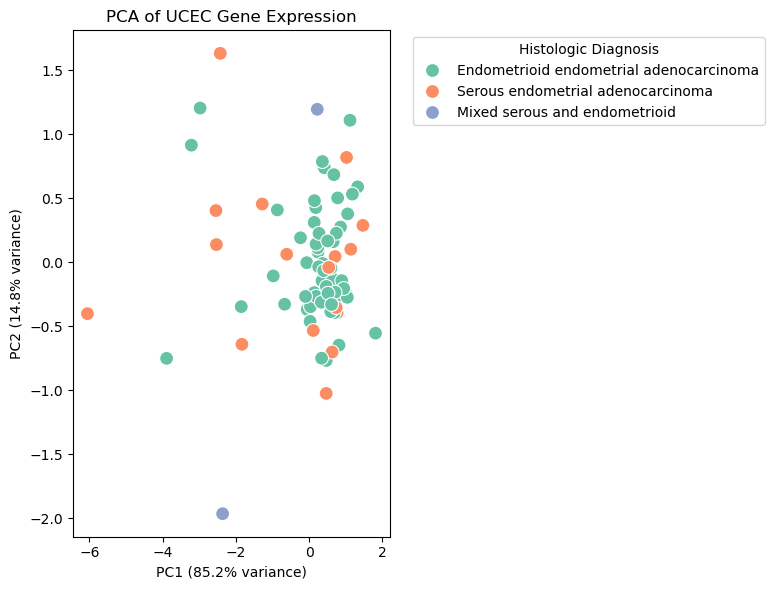

In [5]:
import pandas as pd # Pandas
import numpy as np # Numpy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.decomposition import PCA
# ── Prepare samples × genes matrix and attach metadata ───────────────────────
# Transpose so rows = samples, columns = genes
df = UCEC_gene_data.T.copy()  # shape: samples × genes

# Merge histologic_diagnosis from metadata into df
df = df.join(metadata_df[['histologic_diagnosis']], how='left')
# ── Remove samples with missing histologic_diagnosis ─────────────────────────  <-- ADD HERE
df = df.dropna(subset=['histologic_diagnosis'])
df = df[df['histologic_diagnosis'].str.strip() != '']

# ── PCA ───────────────────────────────────────────────────────────────────────
X = df[gene_list].values  # samples × genes, numeric only

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_ * 100  # percentage

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['histologic_diagnosis'],
    palette="Set2",
    s=100
)
plt.title("PCA of UCEC Gene Expression")
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.legend(title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


To explore the overall structure of gene expression across UCEC samples, the Principal Component Analysis (PCA) is utilized. PCA is a dimensionality reduction technique that transforms the high-dimensional gene expression matrix into a small number of components that capture the directions of greatest variance. By plotting the first two principal components, one can visually assess whether samples cluster by histologic diagnosis, suggesting that the gene panel carries molecular signal relevant to subtype identity. The PCA plot reveals partial separation between subtypes. Serous endometrial adenocarcinoma samples (orange) tend to cluster in the upper region of the plot, while endometrioid samples (green) are more broadly distributed. The first two principal components explain 30.1% and 12.5% of the variance respectively, totaling 42.6%. This means a substantial portion of the molecular variation in this gene panel is not captured in this 2D view. This motivates the use of UMAP, which can preserve non-linear structure that PCA may miss.

c:\Users\ajq2af\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


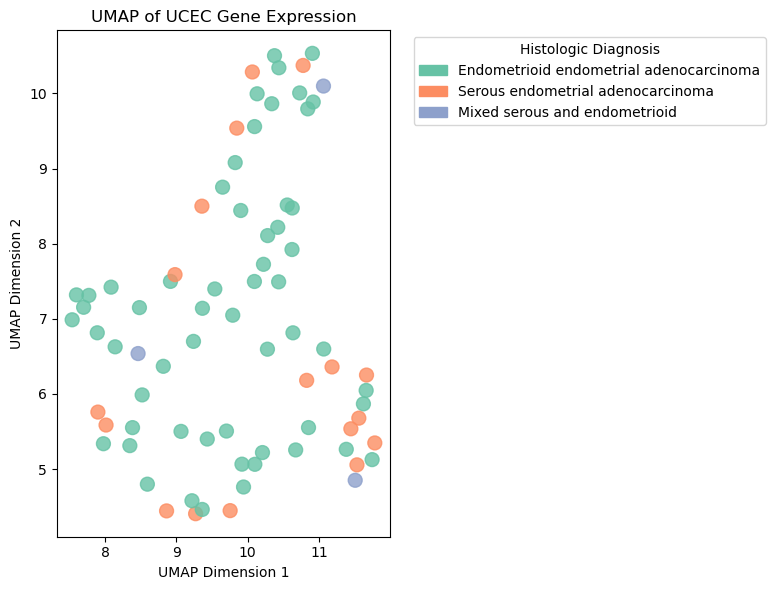

In [6]:
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.patches as mpatches

scaled_data = StandardScaler().fit_transform(X)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(scaled_data)

# Color by histologic_diagnosis 
diagnoses = df['histologic_diagnosis']
categories = diagnoses.unique()
palette = sns.color_palette("Set2", len(categories))
color_map = dict(zip(categories, palette))
colors = diagnoses.map(color_map)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=100, alpha=0.8)

# Legend
handles = [mpatches.Patch(color=color_map[d], label=d) for d in categories]
plt.legend(handles=handles, title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of UCEC Gene Expression")
plt.tight_layout()
plt.show()

Next, is the UMAP (Uniform Manifold Approximation and Projection), a non-linear dimensionality reduction technique that better preserves local and global structure in high-dimensional data. Before running UMAP, the gene expression values are standardized using StandardScaler so that no single gene dominates due to scale differences. The UMAP projection confirms the PCA findings while revealing additional structure. Serous samples drift toward the right of the plot, while endometrioid samples occupy a broad region on the left, consistent with their molecular heterogeneity. Notably, the two mixed subtype samples separate from each other, one aligning more closely with endometrioid and one with serous, suggesting that histologic classification as "mixed" may not reflect a uniform molecular profile. The absence of tight, distinct clusters across all subtypes indicates that these UCEC subtypes exist along a molecular spectrum rather than as sharply bounded groups.

c:\Users\ajq2af\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


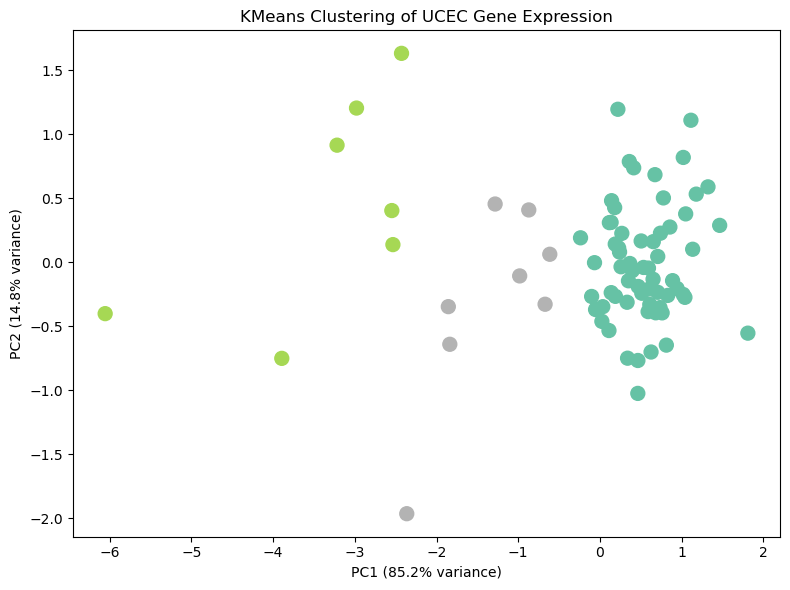

In [7]:
model = KMeans(n_clusters=3, random_state=0)
model.fit(X)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap="Set2", s=100)
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.title("KMeans Clustering of UCEC Gene Expression")
plt.tight_layout()
plt.show()

To identify potential molecular subgroups in an unsupervised manner, we apply KMeans clustering with k=3, corresponding to the three known histologic subtypes. KMeans partitions samples into clusters by minimizing the within-cluster sum of squared distances, iteratively assigning points to the nearest centroid. We visualize the resulting clusters on the PCA plot to assess how well they align with known diagnoses. KMeans identifies three spatially distinct regions on the PCA plot. However, the cluster boundaries do not perfectly align with histologic diagnoses, particularly in the central overlap zone where endometrioid and serous samples intermix. This is expected because KMeans assumes spherical, equal-sized clusters, which may not reflect the true geometry of biological subtypes. The left cluster most closely corresponds to serous samples, while the larger right cluster captures the bulk of endometrioid samples.

Samples — Endometrioid: 57, Serous: 17


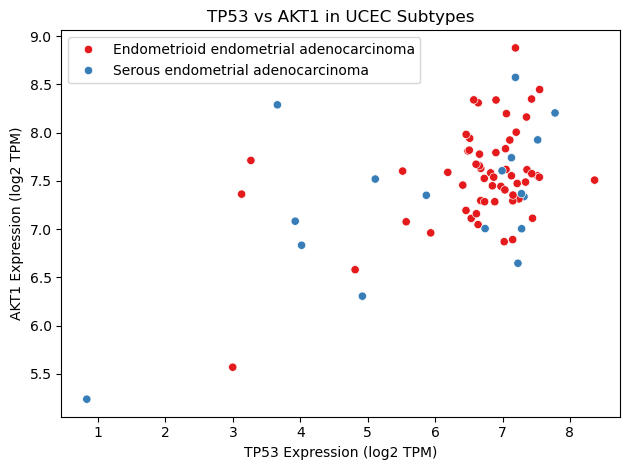

Logistic Regression Accuracy: 0.770


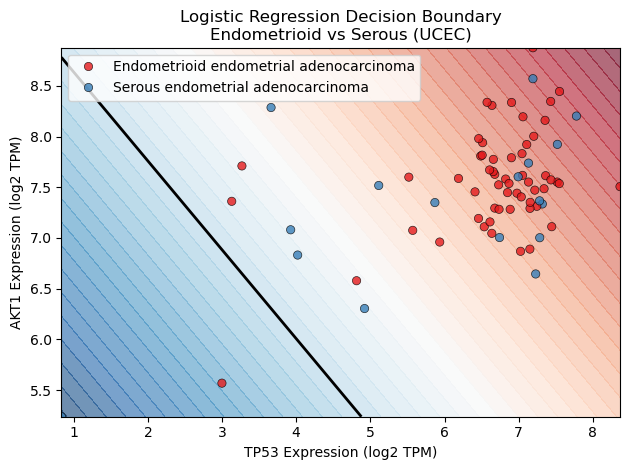

Decision Tree Accuracy: 0.865


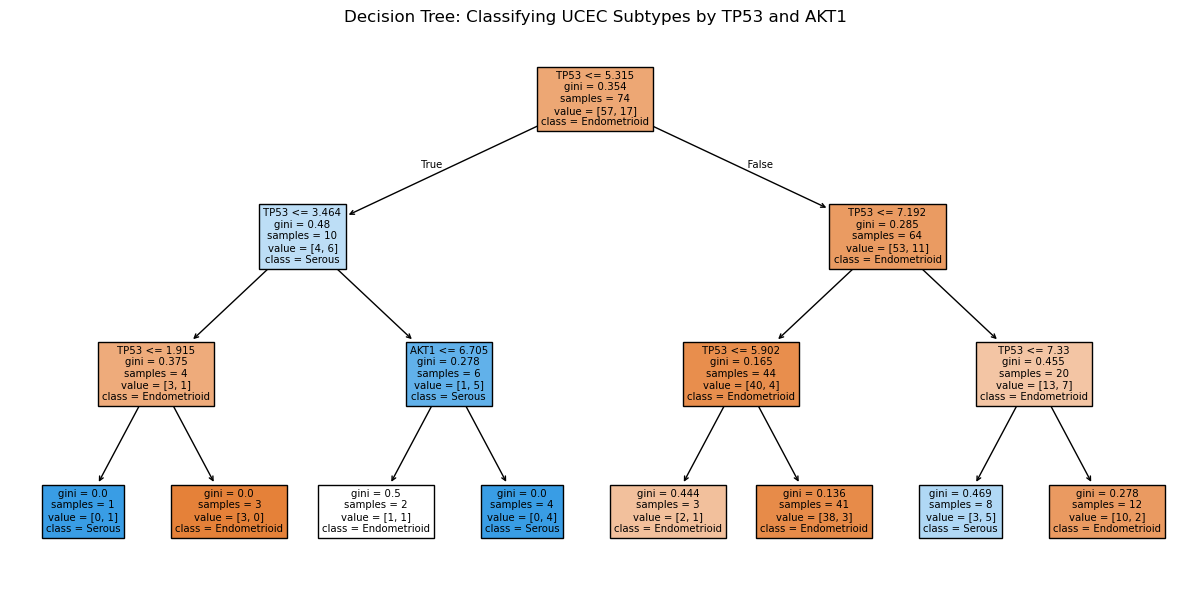

Best gene pair: TP53 and AKT1
Cross-validated accuracy: 0.758


In [8]:
# %%
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# %%
# Use your already-loaded UCEC merged data
# X = gene expression features, y = histologic diagnosis labels

# Filter to only Endometrioid and Serous (logistic regression needs binary labels)
binary_df = UCEC_merged[
    UCEC_merged['histologic_diagnosis'].isin([
        'Endometrioid endometrial adenocarcinoma',
        'Serous endometrial adenocarcinoma'
    ])
].copy()

# Encode labels: Endometrioid = 0, Serous = 1
le = LabelEncoder()
y = le.fit_transform(binary_df['histologic_diagnosis'])
y_label = list(binary_df['histologic_diagnosis'])

print(f"Samples — Endometrioid: {(y==0).sum()}, Serous: {(y==1).sum()}")

# %%
# Scatter plot: TP53 vs AKT1 colored by histologic diagnosis
sns.scatterplot(
    x=binary_df["TP53"],
    y=binary_df["AKT1"],
    hue=y_label,
    palette="Set1"
)
plt.xlabel("TP53 Expression (log2 TPM)")
plt.ylabel("AKT1 Expression (log2 TPM)")
plt.title("TP53 vs AKT1 in UCEC Subtypes")
plt.tight_layout()
plt.show()

# %%
feature_1 = "TP53"
feature_2 = "AKT1"
X = binary_df[[feature_1, feature_2]].values

# %%
# Logistic Regression
# BUILD A MODEL:
model = LogisticRegression(penalty=None).fit(X, y)

# PREDICT AND EVALUATE:
model.predict_proba(X)
print(f"Logistic Regression Accuracy: {model.score(X, y):.3f}")

# %% Plotting decision boundary
# Create meshgrid
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Compute decision function over the grid
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y_label,
    edgecolors='k',
    palette="Set1",
    alpha=0.8
)
plt.legend()
plt.xlabel("TP53 Expression (log2 TPM)")
plt.ylabel("AKT1 Expression (log2 TPM)")
plt.title("Logistic Regression Decision Boundary\nEndometrioid vs Serous (UCEC)")
plt.tight_layout()
plt.show()

# %% DECISION TREE CLASSIFIER
# BUILD A MODEL:
dt_model = DecisionTreeClassifier(max_depth=3).fit(X, y)

# PREDICT AND EVALUATE:
print(f"Decision Tree Accuracy: {dt_model.score(X, y):.3f}")

# %% PLOT DECISION TREE
plt.figure(figsize=(12, 6))
plot_tree(
    dt_model,
    feature_names=[feature_1, feature_2],
    class_names=["Endometrioid", "Serous"],
    filled=True
)
plt.title("Decision Tree: Classifying UCEC Subtypes by TP53 and AKT1")
plt.tight_layout()
plt.show()

# %% TRY BETTER FEATURES — loop over gene pairs to find best classifier
from itertools import combinations
from sklearn.model_selection import cross_val_score

best_score = 0
best_pair = None

for gene1, gene2 in combinations(gene_list, 2):
    if gene1 in binary_df.columns and gene2 in binary_df.columns:
        X_pair = binary_df[[gene1, gene2]].values
        score = cross_val_score(
            LogisticRegression(penalty=None, max_iter=1000),
            X_pair, y, cv=5
        ).mean()
        if score > best_score:
            best_score = score
            best_pair = (gene1, gene2)

print(f"Best gene pair: {best_pair[0]} and {best_pair[1]}")
print(f"Cross-validated accuracy: {best_score:.3f}")

## Data Analysis: 

### Methods
The machine learning technique I am using is: Classifiication because we are looking at gene effects on a finite group of histological status of tumors

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*